# Classificação com dados desbalanceados

## Carregando base de dados

In [1]:
import pandas as pd
import random
import numpy as np

In [3]:
dataset = pd.read_csv('../Bases de dados/credit_data.csv')

In [4]:
dataset.shape

(2000, 5)

In [17]:
"""
A base credit_data foi criada com o objetivo de estudar o comportamento financeiro de clientes e prever o risco
de inadimplência em operações de crédito. Ela é comumente utilizada em projetos de aprendizado de máquina e análise preditiva.

A base contém informações como idade, renda, valor do empréstimo e se o cliente ficou inadimplente. Essa amostra contém 2.000 registros.
+++++++++++++++++++++++ METADADOS +++++++++++++++++++++++
    | Coluna     | Descrição                                                                 |
    |------------|---------------------------------------------------------------------------|
    | `clientid` | Identificador único de cada cliente (número sequencial).                  |
    | `income`   | Renda mensal do cliente (em reais ou dólares, dependendo da base usada).  |
    | `age`      | Idade do cliente (em anos).                                               |
    | `loan`     | Valor do empréstimo tomado pelo cliente.                                  |
    | `default`  | Indicador de inadimplência: `1` para inadimplente, `0` para adimplente.   |
"""

dataset.head()

# 0 PAGOU A DIVIDA(LOAN)
# 1 NÃO PAGOU A SUA DÍVIDA(LOAN)

,i#clientid,income,age,loan,c#default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


In [7]:
# Realizando limpeza dos dados nulos
# inplace indica que não é necessário criar uma nova variável
dataset.dropna(inplace=True)
dataset.shape

(1997, 5)

In [14]:
dataset['c#default'].value_counts()

c#default
0    1714
1     283
Name: count, dtype: int64

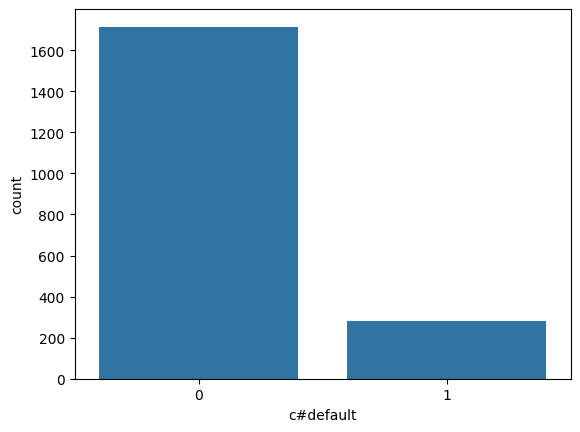

In [ ]:
import seaborn as sns

# Podemos observar que os valores da classificação estão desbalanceados
# Por esse motivo o modelo pode não aprender da melhor forma
# Por se tratar de algoritmos matemáticos os dados precisam estar alinhados e balanceados.
sns.countplot(dataset, x="c#default");

## Bases de treino e teste

In [ ]:
# Separando a base entre atributos previsores X e o previsor y(target alvo)
# todas as linas:colunas income,a ge e loan
X = dataset.iloc[:, 1:4].values
y = dataset.iloc[:, 4].values

In [15]:
X.shape, y.shape


((1997, 3), (1997,))

In [14]:
X

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]], shape=(1997, 3))

In [16]:
y

array([0, 0, 0, ..., 1, 0, 0], shape=(1997,))

In [18]:
from sklearn.model_selection import train_test_split

# Realizando amostragem estratificada
# Separando dados de treino(80% da base total) e teste(20% da base total)
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X,y, test_size=0.2, stratify=y)

In [19]:
# A quantidade de linhas entre o X e Y devem ser iguais
X_treinamento.shape, y_treinamento.shape

((1597, 3), (1597,))

In [20]:
X_teste.shape, y_teste.shape

((400, 3), (400,))

In [27]:
# Calculo basico para saber em % a quantidade de cada classificador 0 e 1 -> dataset original
total_original = len(dataset)
qtd_zero = int(np.unique(y, return_counts=True)[1][0])
qtd_um = int(np.unique(y, return_counts=True)[1][1])

print(f"Total de clientes na base original: {total_original}")
print(f"Quantidade de clientes que pagaram suas dívdias: {qtd_zero} --> {(qtd_zero / total_original) * 100:.2f}%")
print(f"Quantidade de clientes que não pagaram suas dívdias: {qtd_um} --> {(qtd_um / total_original) * 100:.2f}%")

# Validando se a nossa amostra estratificada de treinamento relfete o mesmo tamanho que o dataset original
total_treinamento = len(y_treinamento)
qtd_zero_treino = int(np.unique(y_treinamento, return_counts=True)[1][0])
qtd_um_treino = int(np.unique(y_treinamento, return_counts=True)[1][1])

print(f"\n\nTotal de clientes na base de treinametno: {total_treinamento}")
print(f"Quantidade de clientes que pagaram suas dívdias: {qtd_zero_treino} --> {(qtd_zero_treino / total_treinamento) * 100:.2f}%")
print(f"Quantidade de clientes que não pagaram suas dívdias: {qtd_um_treino} --> {(qtd_um_treino / total_treinamento) * 100:.2f}%")

# Validando se a nossa amostra estratificada de teste relfete o mesmo tamanho que o dataset original
total_teste = len(y_teste)
qtd_zero_teste = int(np.unique(y_teste, return_counts=True)[1][0])
qtd_um_teste = int(np.unique(y_teste, return_counts=True)[1][1])

print(f"\n\nTotal de clientes na base de teste: {total_teste}")
print(f"Quantidade de clientes que pagaram suas dívdias: {qtd_zero_teste} --> {(qtd_zero_teste / total_teste) * 100:.2f}%")
print(f"Quantidade de clientes que não pagaram suas dívdias: {qtd_um_teste} --> {(qtd_um_teste / total_teste) * 100:.2f}%")

Total de clientes na base original: 1997
Quantidade de clientes que pagaram suas dívdias: 1714 --> 85.83%
Quantidade de clientes que não pagaram suas dívdias: 283 --> 14.17%


Total de clientes na base de treinametno: 1597
Quantidade de clientes que pagaram suas dívdias: 1371 --> 85.85%
Quantidade de clientes que não pagaram suas dívdias: 226 --> 14.15%


Total de clientes na base de teste: 400
Quantidade de clientes que pagaram suas dívdias: 343 --> 85.75%
Quantidade de clientes que não pagaram suas dívdias: 57 --> 14.25%


## Classificando modelo com Algortimo Naive Bayes

In [28]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Realizando o treino do modelo e "fitando" os dados de treinamento para que o algoritmo possa aprender com os dados históricos
modelo = GaussianNB()
modelo.fit(X_treinamento, y_treinamento)

GaussianNB()

In [35]:
previsoes = modelo.predict(X_teste)
previsoes

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [33]:
y_teste

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [37]:
# Realizando o comparativo e validar acurácia do modelo
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(previsoes, y_teste) # 93% de acerto

0.93

In [45]:
matriz = confusion_matrix(previsoes, y_teste)
matriz

array([[337,  22],
       [  6,  35]])

<Axes: >

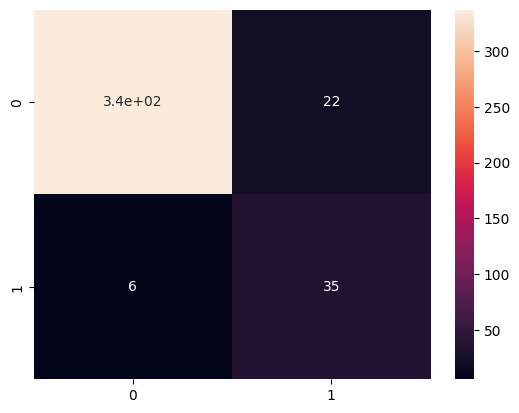

In [44]:
sns.heatmap(matriz, annot=True)

In [ ]:
# Percentual de pessoas que pagam o empréstimos
337 / (337 +22)

0.9387186629526463

In [ ]:
# Percentual de pessoas que não pagam o empréstimos
# Podemos observar que o algoritmo consegue prever ainda melhor as pessoas que pagam empréstimo, pois temos mais dados para esse cenário.
# Isso ocorre quando há dados desbalanceados.
35 / (35 + 6)


0.8536585365853658

In [56]:
# Validando em exemplos, possíveis prejuizos para uma instituição caso o banco aprove um empréstimo mas que o algotimo preveu que ele não vai quitar sua dívida.

# Perdas: R$5.000 para cada cliente que não paga o empréstimo
# Supondo que em nossa base temos 1000 clientes não pagadores
prejuizo = 5000
cliente_nao_pagadores = 1000

# Vamos calcular a quantidade de clientes que o algotimoa cima não preveu -> sobra dos 85% de pessoas que não pagam o empréstimos
qtd_clientes_nao_pagadores = cliente_nao_pagadores * 18 / 100
prejuizo_total = qtd_clientes_nao_pagadores * prejuizo

prejuizo_total

900000.0

In [54]:
180 * 5000

900000